# Washington State GHG Emissions: Who Bears the Burden?

**AD450 Final Project — Daniel Rice, Daniel Merced, Phakphoom, Veer**

## Thesis
The burden of industrial greenhouse gas emissions falls unevenly across Washington State. Rural, lower-income counties bear a disproportionate per-capita emissions load compared to wealthier, more populated urban counties.

## Datasets
1. **WA GHG Reporting Program** — Facility-level emissions reported to the state (2012–2023). Source: [data.wa.gov](https://data.wa.gov/)
2. **US Census County Population Estimates** — Annual county population (2012–2023). Source: [census.gov](https://www.census.gov/programs-surveys/popest/data/data-sets.html)
3. **SAIPE Income & Poverty Estimates** — Median household income and poverty rate by county (2024 snapshot). Source: [census.gov SAIPE](https://www.census.gov/programs-surveys/saipe.html)

## Guiding Questions
1. Which counties emit the most greenhouse gases *per person*, and how does that differ from total emissions?
2. How have emissions changed over time across different sectors?
3. Is there a relationship between a county's median income and its per-capita emissions burden?
4. Which industrial sectors dominate emissions in the counties that bear the heaviest per-capita burden?

---
## 1. Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
!pip install xlrd

In [4]:
# Read the GHG raw data
ghg_url = "https://data.wa.gov/api/views/idhm-59de/rows.csv?accessType=DOWNLOAD"
ghg_path = "./data/raw/GHG_Reporting_Program_Publication.csv"

if os.path.exists(ghg_path):
    ghg_raw = pd.read_csv(ghg_path)
else:
    ghg_raw = pd.read_csv(ghg_url)
    ghg_raw.to_csv(ghg_path, index=False)

ghg_raw.head()


,Reporter,Year,Sector,Subsector,Primary NAICS Code,NAICS Definition,Parent Company,City,County,Jurisdiction,...,HFCs (MTCO2e),PFCs (MTCO2e),Sulfur Hexafluoride (MTCO2e),Fluorinated - Other (MTCO2e),Notes,Point Size,Location,Covered Emissions (MT CO2e),CCA Status,Georeferenced Location
0,Northwest Hardwoods Inc. - Centralia,2022,Wood Products,Lumber Mills,321113.0,Sawmills,Littlejohn & Co. LLC,Centralia,Lewis,Southwest Clean Air Agency,...,0.0,0.0,0.0,0.0,NaN,1.0,"46.734454, -122.991963",NaN,NaN,POINT (-122.991963 46.734454)
1,Seattle-Tacoma International Airport - Seattle,2021,Government,Other Government,488119.0,Other Airport Operations,Port of Seattle,Seattle,King,Puget Sound Clean Air Agency,...,0.0,0.0,0.0,0.0,NaN,1.0,"47.443643, -122.302452",NaN,NaN,POINT (-122.302452 47.443643)
2,Avista Corporation - supplier,2018,Supplier,Natural Gas Supplier,NaN,NaN,Avista Corporation,Spokane,Spokane,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Avista - EPE - Spokane,2022,Power,IOU,NaN,NaN,Avista Corporation,Spokane,Spokane,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Public Utility District No. 1 of Grays Harbor ...,2022,Power,COU,2211.0,"Electric Power Generation, Transmission and Di...",Public Utility District No. 1 of Grays Harbor ...,Aberdeen,Grays Harbor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Census Data Sets

# Data for 2020-2024
raw_census_2020_to_2024 = pd.read_excel("data/raw/co-est2024-pop-53.xlsx", skiprows=3, header=0)

# Data for 2010-2019
raw_census_2010_to_2019 = pd.read_excel("data/raw/co-est2020int-pop-53.xlsx", skiprows=3, header=0)

In [6]:
# Income Data Sets

raw_income = pd.read_excel("data/raw/est24all.xls", skiprows=3, header=0)

---
## 2. Exploratory Data Analysis (EDA)

Before cleaning or joining anything, we explore the raw GHG dataset to understand its shape, contents, and quirks.

### 2.1 Summarize the data (Daniel Rice)
Use `.info()`, `.shape`, and `.head()` to understand the structure of the GHG dataset — column names, dtypes, non-null counts, and a preview of actual values.

In [7]:
# TODO (Daniel Rice): Summarize ghg_raw — .shape, .info(), .head()
print(ghg_raw.info())

print(ghg_raw.shape)

print(ghg_raw.head())


<class 'pandas.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Reporter                          2226 non-null   str    
 1   Year                              2226 non-null   int64  
 2   Sector                            2225 non-null   str    
 3   Subsector                         2225 non-null   str    
 4   Primary NAICS Code                2198 non-null   float64
 5   NAICS Definition                  2198 non-null   str    
 6   Parent Company                    2216 non-null   str    
 7   City                              2225 non-null   str    
 8   County                            2225 non-null   str    
 9   Jurisdiction                      1994 non-null   str    
 10  Reported Emissions (MTCO2e)       2223 non-null   float64
 11  Biogenic Carbon Dioxide (MTCO2e)  2159 non-null   float64
 12  Carbon Dioxide (M

### 2.2 Basic statistics on numeric columns (Daniel Merced)
Use `.describe()` on the numeric emissions columns. What is the range of reported emissions? What does the distribution look like (mean vs median)? Are there zeros?

In [8]:
# TODO (Daniel Merced): .describe() on numeric columns, especially emissions columns
# Note any large differences between mean and median (indicates skew/outliers)

# numeric emissions-related columns
emissions_numeric = ghg_raw.select_dtypes(include="number")

# summary statistics
emissions_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2226.0,2018.005391,3.549707e+00,2012.0,2015.0,2018.0,2021.0,2023.0
Primary NAICS Code,2198.0,360493.103276,1.559330e+05,2211.0,311411.0,322130.0,424710.0,928110.0
Reported Emissions (MTCO2e),2223.0,251384.089519,7.754844e+05,0.0,16188.5,36801.0,106314.5,8911628.0
Biogenic Carbon Dioxide (MTCO2e),2159.0,42790.459009,1.752620e+05,0.0,0.0,0.0,0.0,1627697.0
Carbon Dioxide (MTCO2e),2159.0,192749.316813,7.443682e+05,0.0,1975.0,17582.0,61764.0,8415579.0
Methane (MTCO2e),2159.0,8533.169060,3.178184e+04,0.0,10.0,63.0,2059.5,348592.0
Nitrous Oxide (MTCO2e),2159.0,2151.232978,1.146719e+04,0.0,8.0,27.0,374.5,176178.0
HFCs (MTCO2e),2159.0,65.098657,7.438371e+02,0.0,0.0,0.0,0.0,11841.0
PFCs (MTCO2e),2159.0,3553.637795,4.863256e+04,0.0,0.0,0.0,0.0,884344.0
Sulfur Hexafluoride (MTCO2e),2159.0,290.912923,2.667460e+03,0.0,0.0,0.0,0.0,45978.0


### 2.3 Value counts of categorical columns (Phakphoom)
Use `.value_counts()` on Sector, County, and City to understand the categorical distribution. How many unique sectors? Which counties appear most often? Are there any unexpected values (e.g., out-of-state counties)?

In [9]:
# TODO (Phakphoom): value_counts() for Sector, County, and City
# Flag any counties that are NOT in Washington State
print(raw_census_2010_to_2019[~raw_census_2010_to_2019['Unnamed: 0'].str.contains('Washington')].shape[0])
print(raw_census_2020_to_2024[~raw_census_2020_to_2024['Unnamed: 0'].str.contains('Washington')].shape[0])
print(raw_income[~raw_income['Postal Code'].str.contains('WA')].shape[0])

5
5
3156


### 2.4 Histograms of numeric columns (Veer)
Plot histograms of `Reported Emissions (MTCO2e)` and at least one gas breakdown column (e.g., Carbon Dioxide, Methane). Are emissions normally distributed or heavily skewed?

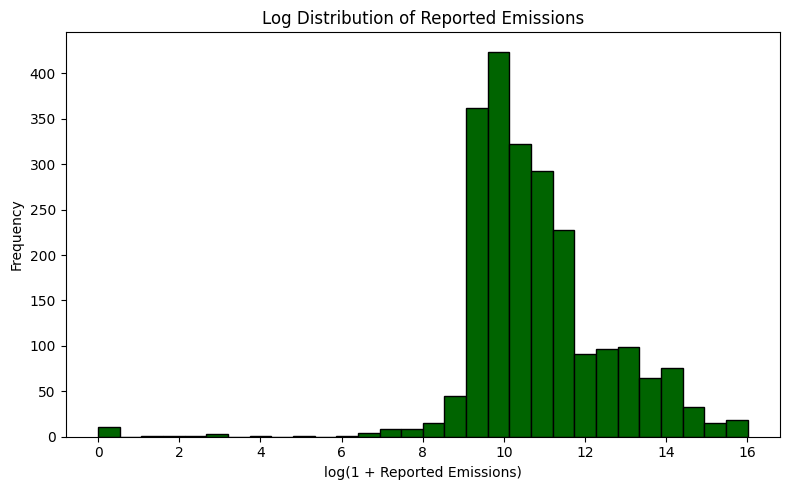

In [10]:
# TODO (Veer): Histograms of Reported Emissions and at least one gas breakdown column
# Consider using log scale if the distribution is extremely skewed

# Log histogram for Reported Emissions
plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(ghg_raw['Reported Emissions (MTCO2e)'].dropna()),
    bins=30,
    color='darkgreen',
    edgecolor='black'
)
plt.title('Log Distribution of Reported Emissions')
plt.xlabel('log(1 + Reported Emissions)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

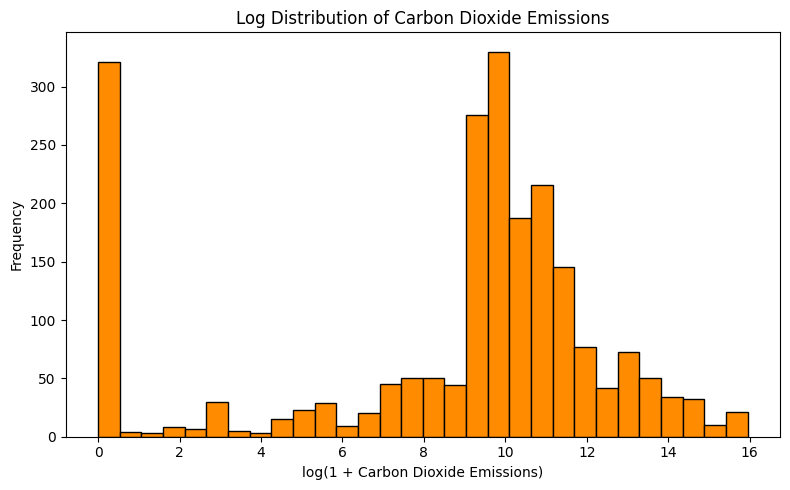

In [11]:
# Log histogram for Carbon Dioxide
plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(ghg_raw['Carbon Dioxide (MTCO2e)'].dropna()),
    bins=30,
    color='darkorange',
    edgecolor='black'
)
plt.title('Log Distribution of Carbon Dioxide Emissions')
plt.xlabel('log(1 + Carbon Dioxide Emissions)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning & Transformation

The raw data has null values, dtype issues, out-of-state rows, and columns we need to derive. We clean all three datasets in this section.

### 3.1 Correct data dtype issues (Daniel Rice)
- Ensure `Year` is int (not float).
- Parse the `Location` column (lat, lon string) into separate `Latitude` and `Longitude` float columns.
- Fix `Primary NAICS Code` to a clean numeric or string type.
- Also clean the census population dataframes: rename the first column to `County`, strip the leading dot and trailing `, Washington` from county names, drop the state total row, and ensure year columns are int.

In [12]:
# TODO (Daniel Rice): Fix dtypes in ghg_raw
# Also clean raw_census_2010_to_2019 and raw_census_2020_to_2024:
#   - Rename first col to 'County'
#   - Strip leading '.' and trailing ' County, Washington' from county names
#   - Drop the state total row (first data row = 'Washington')
#   - Keep only year columns we need (2012-2019 from the first file, 2020-2023 from the second)

# === Fix dtypes in ghg_raw ===

# Year is already int64, confirmed via .info() — no fix needed

# Parse Location column ("lat, lon" string) into separate float columns
ghg_raw[['Latitude', 'Longitude']] = (
    ghg_raw['Location']
    .str.split(',', expand=True)
    .astype(float)
)

# Clean NAICS code — drop decimal, convert to nullable Int64
ghg_raw['Primary NAICS Code'] = ghg_raw['Primary NAICS Code'].astype('Int64')


# === Clean census 2010-2019 ===

# Rename first column
raw_census_2010_to_2019 = raw_census_2010_to_2019.rename(columns={raw_census_2010_to_2019.columns[0]: 'County'})

# Drop state total row
raw_census_2010_to_2019 = raw_census_2010_to_2019[raw_census_2010_to_2019['County'] != 'Washington']

# Clean county names: ".Adams County, Washington" -> "Adams"
raw_census_2010_to_2019['County'] = (
    raw_census_2010_to_2019['County']
    .str.lstrip('.')
    .str.replace(' County, Washington', '', regex=False)
)

# Keep only 2012-2019 columns (drop 2010, 2011, April 2020 Census, and the April 2010 base)
year_cols_2010s = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
census_2012_2019 = raw_census_2010_to_2019[['County'] + year_cols_2010s].copy()


# === Clean census 2020-2024 ===

raw_census_2020_to_2024 = raw_census_2020_to_2024.rename(columns={raw_census_2020_to_2024.columns[0]: 'County'})
raw_census_2020_to_2024 = raw_census_2020_to_2024[raw_census_2020_to_2024['County'] != 'Washington']

raw_census_2020_to_2024['County'] = (
    raw_census_2020_to_2024['County']
    .str.lstrip('.')
    .str.replace(' County, Washington', '', regex=False)
)

# Keep only 2020-2023 (drop April 2020 base and 2024)
year_cols_2020s = [2020, 2021, 2022, 2023]
census_2020_2023 = raw_census_2020_to_2024[['County'] + year_cols_2020s].copy()

### 3.2 Fill NaN values (Daniel Merced)
The gas breakdown columns (Carbon Dioxide, Methane, Nitrous Oxide, HFCs, PFCs, SF6, Fluorinated-Other) have 67 null rows each. Decide on a fill strategy:
- If the row has a `Reported Emissions` value but missing breakdowns, fill gas columns with 0 (they weren't reported, not necessarily absent).
- The `Jurisdiction` column has ~232 nulls — fill with `'Unknown'` or investigate.
- Document your reasoning.

In [13]:
# TODO (Daniel Merced): Fill NaN values in emissions breakdown columns and Jurisdiction
# Print null counts before and after to show the work

gas_cols = [
    "Biogenic Carbon Dioxide (MTCO2e)",
    "Carbon Dioxide (MTCO2e)",
    "Methane (MTCO2e)",
    "Nitrous Oxide (MTCO2e)",
    "HFCs (MTCO2e)",
    "PFCs (MTCO2e)",
    "Sulfur Hexafluoride (MTCO2e)",
    "Fluorinated - Other (MTCO2e)"
]

reported_col = "Reported Emissions (MTCO2e)"
jurisdiction_col = "Jurisdiction"

# null counts before
print("Null counts before fill:\n")
print(ghg_raw[gas_cols + [jurisdiction_col]].isna().sum())

# fill gas breakdowns with 0 when total reported emissions exists
has_reported = ghg_raw[reported_col].notna()
ghg_raw.loc[has_reported, gas_cols] = ghg_raw.loc[has_reported, gas_cols].fillna(0)

# fill missing jurisdiction with Unknown
ghg_raw[jurisdiction_col] = ghg_raw[jurisdiction_col].fillna("Unknown")

# null counts after
print("\nNull counts after fill:\n")
print(ghg_raw[gas_cols + [jurisdiction_col]].isna().sum())

# 64 rows had missing gas breakdowns but did have a 
# total reported emissions value, so they were filled with 0
# 3 rows had missing gas breakdowns and also did not have a 
# reported emissions value, so they stayed missing

Null counts before fill:

Biogenic Carbon Dioxide (MTCO2e)     67
Carbon Dioxide (MTCO2e)              67
Methane (MTCO2e)                     67
Nitrous Oxide (MTCO2e)               67
HFCs (MTCO2e)                        67
PFCs (MTCO2e)                        67
Sulfur Hexafluoride (MTCO2e)         67
Fluorinated - Other (MTCO2e)         67
Jurisdiction                        232
dtype: int64

Null counts after fill:

Biogenic Carbon Dioxide (MTCO2e)    3
Carbon Dioxide (MTCO2e)             3
Methane (MTCO2e)                    3
Nitrous Oxide (MTCO2e)              3
HFCs (MTCO2e)                       3
PFCs (MTCO2e)                       3
Sulfur Hexafluoride (MTCO2e)        3
Fluorinated - Other (MTCO2e)        3
Jurisdiction                        0
dtype: int64


### 3.3 Remove inaccurate / out-of-scope data (Phakphoom)
The County value_counts revealed non-WA counties (e.g., `Greater Vancouver`, `Umatilla`, `Sonoma`, `Los Angeles`). These are facilities that report to WA but are physically located elsewhere.
- Identify and remove rows where County is not a valid WA county.
- Also remove the `Supplier` sector rows — these represent fuel suppliers, not physical emitters in a location, and will distort per-capita analysis.
- Document how many rows are removed and why.

In [14]:
# TODO (Phakphoom): Remove out-of-state counties and Supplier sector rows
# Print row count before and after, and list the removed counties

### 3.4 Add derivative columns (Veer)
Create new columns that will power our analysis:
- `Non_CO2_Emissions`: sum of Methane + Nitrous Oxide + HFCs + PFCs + SF6 + Fluorinated-Other (shows how much of each facility's footprint is non-CO2 gases)
- Clean the income data: filter `raw_income` to WA counties only (`State FIPS Code == 53`, `County FIPS Code != 0`), strip `' County'` from the `Name` column, keep only `Name`, `Poverty Percent, All Ages`, and `Median Household Income`.

In [15]:
# TODO (Veer): Add Non_CO2_Emissions column to ghg_raw
# Also clean raw_income into a tidy income_df with columns: County, Poverty_Pct, Median_Income

# Add Non_CO2_Emissions column to ghg_raw
ghg_raw['Non_CO2_Emissions'] = ghg_raw[
    [
        'Methane (MTCO2e)',
        'Nitrous Oxide (MTCO2e)',
        'HFCs (MTCO2e)',
        'PFCs (MTCO2e)',
        'Sulfur Hexafluoride (MTCO2e)',
        'Fluorinated - Other (MTCO2e)'
    ]
].sum(axis=1)

# Clean raw_income into income_df
income_df = raw_income[
    (raw_income['State FIPS Code'] == 53) &
    (raw_income['County FIPS Code'] != 0)
].copy()

income_df['Name'] = income_df['Name'].str.replace(' County', '', regex=False)

income_df = income_df[
    ['Name', 'Poverty Percent, All Ages', 'Median Household Income']
]

income_df = income_df.rename(columns={
    'Name': 'County',
    'Poverty Percent, All Ages': 'Poverty_Pct',
    'Median Household Income': 'Median_Income'
})

ghg_raw[['Reported Emissions (MTCO2e)', 'Carbon Dioxide (MTCO2e)', 'Non_CO2_Emissions']].head()


,Reported Emissions (MTCO2e),Carbon Dioxide (MTCO2e),Non_CO2_Emissions
0,12065.0,4063.0,110.0
1,14978.0,14963.0,16.0
2,1044525.0,1043447.0,1078.0
3,2259628.0,0.0,0.0
4,29078.0,0.0,0.0


---
## 4. Data Joining

We now combine our three datasets to enable per-capita and income-based analysis.

### 4.1 Concatenate census population dataframes (Daniel Rice)
Melt each cleaned census dataframe from wide to long format (columns: `County`, `Year`, `Population`), then concatenate them into a single `population_df` covering 2012–2023.
- Watch for the 2020 overlap between the two files — pick one.
- Verify shape: should be 39 counties × 12 years = 468 rows.

In [16]:
# Daniel Rice

# Melt 2012-2019 from wide to long
pop_2012_2019 = census_2012_2019.melt(
    id_vars='County',
    var_name='Year',
    value_name='Population'
)

# Melt 2020-2023 from wide to long
pop_2020_2023 = census_2020_2023.melt(
    id_vars='County',
    var_name='Year',
    value_name='Population'
)

# Ensure Year is int (melt can produce float from Excel headers)
pop_2012_2019['Year'] = pop_2012_2019['Year'].astype(int)
pop_2020_2023['Year'] = pop_2020_2023['Year'].astype(int)

# Concatenate into one population dataframe
population_df = pd.concat([pop_2012_2019, pop_2020_2023], ignore_index=True)

# Verify: 39 counties × 12 years = 468 rows
print("Shape:", population_df.shape)
print(population_df.head())
print(population_df.tail(15))

Shape: (540, 3)
    County  Year  Population
0    Adams  2012     19061.0
1   Asotin  2012     21817.0
2   Benton  2012    182595.0
3   Chelan  2012     73826.0
4  Clallam  2012     71607.0
                                                County  Year  Population
525                                          Snohomish  2023    850297.0
526                                            Spokane  2023    552758.0
527                                            Stevens  2023     48838.0
528                                           Thurston  2023    299519.0
529                                          Wahkiakum  2023      4767.0
530                                        Walla Walla  2023     61789.0
531                                            Whatcom  2023    232686.0
532                                            Whitman  2023     47900.0
533                                             Yakima  2023    257193.0
534  The Census Bureau has reviewed this data produ...  2023         NaN
535  No

### 4.2 Merge GHG data with population on County + Year (Daniel Merced)
Use `pd.merge()` to join the cleaned GHG data with `population_df` on `County` and `Year`. This gives every emissions row a population context.
- Use a left merge to keep all GHG rows.
- Check how many rows have null Population after the merge (counties that don't match).

In [17]:
# (Daniel Merced)
# Merge GHG data with population data on County + Year
ghg_with_population = pd.merge(
    ghg_raw,
    population_df,
    on=["County", "Year"],
    how="left"
)

# Check how many rows did not find a population match
null_population_count = ghg_with_population["Population"].isna().sum()

print("Merged shape:", ghg_with_population.shape)
print("Rows with null Population:", null_population_count)

Merged shape: (2226, 29)
Rows with null Population: 130


### 4.3 Merge with income data on County (Phakphoom)
Use `pd.merge()` to join the income/poverty data onto the GHG+population dataframe on `County`.
- This is a many-to-one join (many GHG rows per county, one income row per county).
- Verify the join worked by spot-checking a known county like King or Lewis.

In [18]:
# TODO (Phakphoom): pd.merge() to add Median_Income and Poverty_Pct columns
# Spot-check a couple of counties


### 4.4 Join aggregated dataframes on index (Veer)
To demonstrate index-based joining:
- Create a df of total emissions per county (all years summed), indexed by County.
- Create a df of average population per county (across all years), indexed by County.
- Use `.join()` to combine them on the County index.
- Add a `Per_Capita_Emissions` column (total emissions / avg population).

In [19]:
# TODO (Veer): Create two indexed dfs and .join() them, then compute Per_Capita_Emissions
# This df will be key for the final visualizations

# Keep only WA counties that appear in the population data
ghg_wa = ghg_raw[ghg_raw['County'].isin(population_df['County'])].copy()

# Total emissions per county (all years summed), indexed by County
emissions_by_county = (
    ghg_wa
    .groupby('County')['Reported Emissions (MTCO2e)']
    .sum()
    .to_frame(name='Total_Emissions')
)

# Average population per county (across all years), indexed by County
avg_population_by_county = (
    population_df
    .groupby('County')['Population']
    .mean()
    .to_frame(name='Avg_Population')
)

# Join on County index
county_emissions = emissions_by_county.join(avg_population_by_county)

# Add per-capita emissions column
county_emissions['Per_Capita_Emissions'] = (
    county_emissions['Total_Emissions'] / county_emissions['Avg_Population']
)

county_emissions.sort_values('Per_Capita_Emissions', ascending=False).head(10)

,Total_Emissions,Avg_Population,Per_Capita_Emissions
County,,,
Lewis,80618680.0,79691.833333,1011.630385
Klickitat,11663949.0,22025.333333,529.569692
Cowlitz,51652639.0,107030.083333,482.599260
Skagit,46109740.0,125304.750000,367.980783
Grays Harbor,20927050.0,73688.166667,283.994716
Whatcom,55995858.0,218638.083333,256.112097
Jefferson,6728351.0,31848.916667,211.258394
Walla Walla,11984355.0,61309.916667,195.471722
Columbia,651407.0,3966.500000,164.227152


---
## 5. Aggregation & Grouping Operations

### 5.1 Aggregation on all data (Daniel Rice)
Compute total reported emissions across all of WA for each year (2012–2023). Is the state's total emissions trending up or down?

In [20]:
# (Daniel Rice): Total reported emissions across all of WA, by year
annual_emissions = (
    ghg_wa
    .groupby('Year')['Reported Emissions (MTCO2e)']
    .sum()
    .reset_index()
    .rename(columns={'Reported Emissions (MTCO2e)': 'Total_Emissions'})
)

# Format for readability
annual_emissions['Total_Emissions_M'] = (annual_emissions['Total_Emissions'] / 1e6).round(2)

print("Total WA Industrial Emissions by Year (millions MTCO2e):\n")
print(annual_emissions[['Year', 'Total_Emissions_M']].to_string(index=False))

# Quick trend check
first = annual_emissions.iloc[0]['Total_Emissions']
last = annual_emissions.iloc[-1]['Total_Emissions']
pct_change = ((last - first) / first * 100).round(1)
print(f"\nChange from {annual_emissions.iloc[0]['Year']} to {annual_emissions.iloc[-1]['Year']}: {pct_change}%")

Total WA Industrial Emissions by Year (millions MTCO2e):

 Year  Total_Emissions_M
 2012              27.62
 2013              33.85
 2014              33.78
 2015              40.09
 2016              38.35
 2017              39.84
 2018              38.93
 2019              43.77
 2020              38.39
 2021              37.75
 2022              46.50
 2023              45.94

Change from 2012.0 to 2023.0: 66.3%


### 5.2 Aggregation on a groupby (Daniel Merced)
Group by `Sector` and `Year`, then sum emissions. This reveals which industries are growing or shrinking their footprint over time.

In [21]:
# TODO (Daniel Merced): groupby Sector + Year, sum Reported Emissions
# Display the top 5 sectors' trends


### 5.3 Pivot table — emissions by county and year (Phakphoom)
Create a pivot table with counties as rows, years as columns, and total reported emissions as values. This gives a complete emissions matrix for WA.

In [22]:
# TODO (Phakphoom): pd.pivot_table() — index=County, columns=Year, values=Reported Emissions, aggfunc=sum
# Show the top 10 counties


### 5.4 Cross-tabulation — sector presence by county (Veer)
Create a cross-tabulation showing how many reporting facilities exist for each sector in each county. Which counties have the most diverse industrial base? Which are dominated by a single sector?

In [23]:
# TODO (Veer): pd.crosstab() — County vs Sector, showing facility counts
# Filter to top 10 counties for readability

# Use WA-only data to avoid out-of-state counties
ghg_wa = ghg_raw[ghg_raw['County'].isin(population_df['County'])].copy()

# Create cross-tabulation: County vs Sector (facility counts)
county_sector_crosstab = pd.crosstab(ghg_wa['County'], ghg_wa['Sector'])

# Get top 10 counties by total number of facilities
top10 = county_sector_crosstab.sum(axis=1).sort_values(ascending=False).head(10).index

# Filter to top 10 counties
county_sector_top10 = county_sector_crosstab.loc[top10]

county_sector_top10

Sector,Chemicals,Food Production,Government,Health Care,Livestock,Manufacturing,Metals,Minerals,Natural Gas Systems,Petroleum Systems,Power,Power Plants,Pulp and Paper,Supplier,Waste,Wood Products
County,,,,,,,,,,,,,,,,
King,0,9,24,0,0,60,20,30,12,11,4,31,0,25,12,0
Pierce,0,8,12,0,0,30,0,8,13,12,4,34,31,2,30,15
Cowlitz,24,0,0,0,0,0,12,12,0,0,2,12,36,2,24,12
Spokane,0,0,19,7,0,12,12,8,24,0,4,24,12,9,2,0
Grant,12,60,0,0,10,9,12,12,0,0,2,0,0,0,12,0
Lewis,0,12,0,0,0,0,0,12,18,0,2,24,0,1,0,55
Whatcom,0,12,12,0,0,0,12,0,12,24,0,48,0,0,0,0
Benton,12,31,12,0,12,0,0,0,17,0,6,0,0,13,12,0
Clark,0,24,0,0,0,36,0,0,12,0,2,24,12,2,1,0


---
## 6. Data Visualization & Analysis

We now answer our guiding questions with polished visualizations.

### Q1: Which counties emit the most per person, and how does that differ from total emissions? (Daniel Rice)

Create a side-by-side bar chart (or two ranked bar charts) comparing:
- Top 10 counties by **total** emissions
- Top 10 counties by **per-capita** emissions

The key finding should be visible: counties like King lead in total emissions but are low per-capita, while rural/industrial counties like Lewis or Cowlitz dominate per-capita.

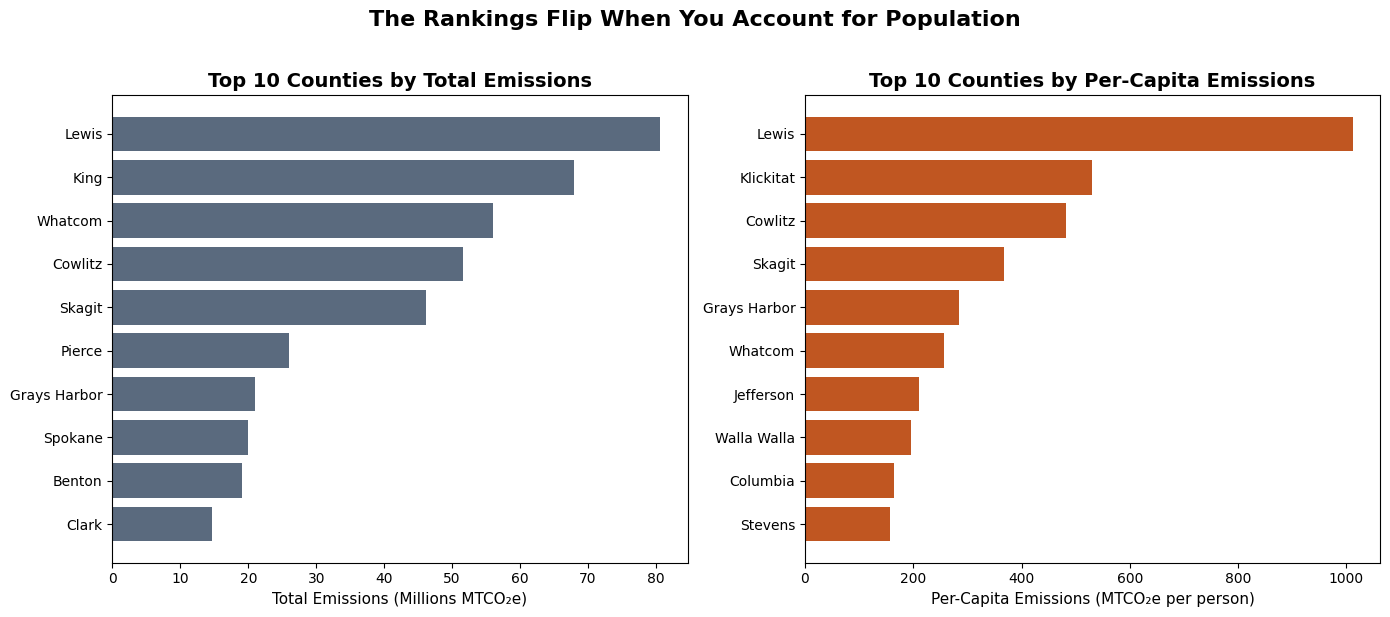

In [24]:
# (Daniel Rice): Side-by-side comparison of total vs per-capita emissions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Top 10 by TOTAL emissions
top_total = county_emissions.sort_values('Total_Emissions', ascending=False).head(10)
axes[0].barh(
    top_total.index[::-1],
    top_total['Total_Emissions'].values[::-1] / 1e6,
    color='#5A6A7E'
)
axes[0].set_xlabel('Total Emissions (Millions MTCO₂e)', fontsize=11)
axes[0].set_title('Top 10 Counties by Total Emissions', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=10)

# Right: Top 10 by PER-CAPITA emissions
top_percap = county_emissions.sort_values('Per_Capita_Emissions', ascending=False).head(10)
axes[1].barh(
    top_percap.index[::-1],
    top_percap['Per_Capita_Emissions'].values[::-1],
    color='#C05621'
)
axes[1].set_xlabel('Per-Capita Emissions (MTCO₂e per person)', fontsize=11)
axes[1].set_title('Top 10 Counties by Per-Capita Emissions', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=10)

fig.suptitle('The Rankings Flip When You Account for Population', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_total_vs_percapita.png', dpi=150, bbox_inches='tight')
plt.show()


King County leads in total emissions but, with 2.4 million residents, its per-capita burden is modest. When we normalize by population, rural industrial counties like Lewis, Cowlitz, and Klickitat surge to the top. These are small communities (often under 100,000 people) with a handful of heavy-emitting facilities. The "who pollutes the most" question has a completely different answer depending on whether you're counting tons or tons-per-person.

### Q2: How have emissions changed over time by sector? (Daniel Merced)

Create a line chart showing total emissions per year for the top 5 sectors. Are any sectors declining? Did COVID (2020) have a visible impact? Annotate or highlight any notable trends.

In [25]:
# TODO (Daniel Merced): Multi-line chart of emissions over time by sector
# Include legend, axis labels, title, and any annotations


*TODO (Daniel Merced): Write 2-3 sentences interpreting the trends visible in this chart.*

### Q3: Is there a relationship between county income and per-capita emissions? (Phakphoom)

Create a scatter plot with:
- X-axis: Median Household Income
- Y-axis: Per-capita emissions
- Optional: size or color by population

Label notable outlier counties. Does lower income correlate with higher emissions burden?

In [26]:
# TODO (Phakphoom): Scatter plot — Median Income vs Per-Capita Emissions
# Label key outlier counties, add title and axis labels


*TODO (Phakphoom): Write 2-3 sentences interpreting the income-emissions relationship. Does this support or challenge the environmental justice thesis?*

### Q4: Which sectors dominate emissions in the highest per-capita counties? (Veer)

Take the top 5 counties by per-capita emissions. Create a stacked bar chart showing the sector breakdown of emissions in each county. Are these counties dominated by one industry, or is the burden spread across sectors?

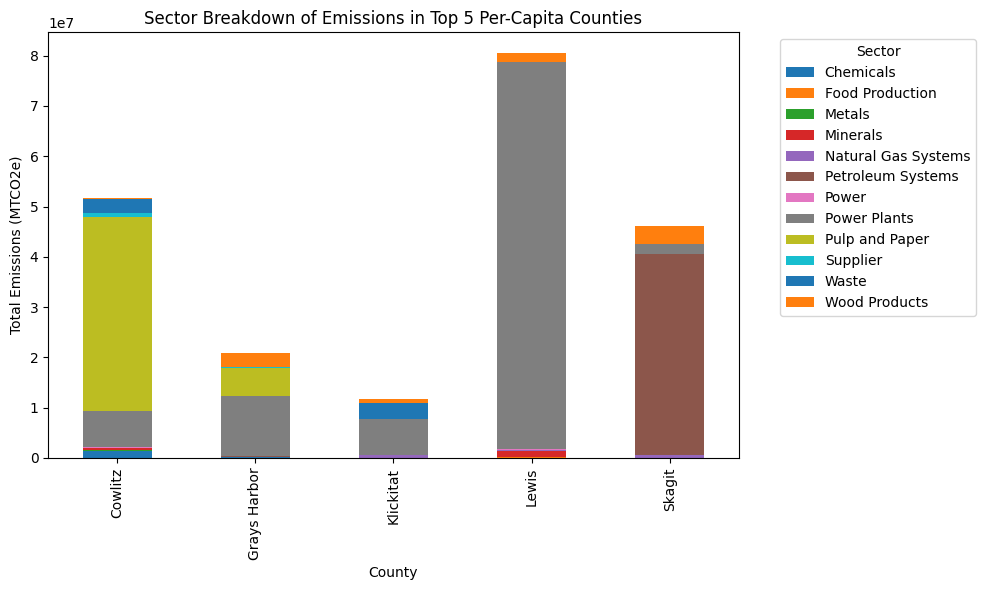

In [29]:
# TODO (Veer): Stacked bar chart — sector breakdown for top 5 per-capita counties
# Clear legend, title, and axis labels

# Get top 5 counties by per-capita emissions
top5 = county_emissions.sort_values('Per_Capita_Emissions', ascending=False).head(5).index

# Filter WA-only data
ghg_wa = ghg_raw[ghg_raw['County'].isin(population_df['County'])].copy()

# Group by County + Sector and sum emissions
sector_emissions = (
    ghg_wa[ghg_wa['County'].isin(top5)]
    .groupby(['County', 'Sector'])['Reported Emissions (MTCO2e)']
    .sum()
    .unstack(fill_value=0)
)

# Plot stacked bar chart
sector_emissions.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Sector Breakdown of Emissions in Top 5 Per-Capita Counties')
plt.xlabel('County')
plt.ylabel('Total Emissions (MTCO2e)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Sector')
plt.tight_layout()
plt.savefig('sector_breakdown_of_emissions_top5_percapita.png', dpi=150, bbox_inches='tight')
plt.show()

The stacked bar chart reveals that emissions in the highest per-capita counties are largely driven by a small number of dominant industries rather than a balanced mix of sectors. For example, counties such as Cowlitz and Lewis are heavily influenced by industries like pulp and paper, power plants, and natural gas systems, which account for the majority of their emissions. This concentration suggests that a few large facilities can significantly increase the per-capita emissions burden in smaller counties, reinforcing the idea that emissions are not evenly distributed across sectors or regions.

*TODO (Veer): Write 2-3 sentences interpreting which industries drive the burden in high per-capita counties.*

---
## 7. Conclusion

*TODO (All): Summarize the key findings:*
- *How does the per-capita picture differ from the total emissions picture?*
- *What role does income play in who bears the emissions burden?*
- *Which sectors are the biggest contributors in the hardest-hit counties?*
- *What are the limitations of this analysis?*